### Valtteri's and Sara's KDs vs course topics 
We use Cohen's kappa for now, because they're just two annotators. 

In [4]:
#!pip install openpyxl

In [3]:
import pandas as pd 
df = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/Topics_Annotation.xlsx')
print(df)

                                                Topic Annotator 1  \
0                                     Ethical Hacking         1,6   
1                  Network and vulnerability scanning           4   
2                       Exploit development platforms         2,7   
3                                 Command and control           0   
4                                   Password cracking           1   
..                                                ...         ...   
74            Policy tools to mitigate market failure         0,5   
75  Key laws and regulations on product liability ...           5   
76  Overview of security industry trends, technolo...           0   
77  Managerial and policy issues in information se...         5,7   
78         When and how policy intervention is needed         NAN   

   Annotator 2  Annotator 3               Sara  Valtteri         Paul  \
0           6,8        2,5,6  0,1,2,3,4,5,6,7,8    2,7,8  3,2,4,5,6,0   
1       3,4,5,7          

In [2]:
# also run the topics through LLM2. 
# Load trained DistilBERT model 
from sklearn.metrics import multilabel_confusion_matrix
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
import sys
import torch
import numpy as np
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")

# load model from a working checkpoint 
model_name='BERTv1final/checkpoint-430' #'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)             # the tokenizer is the same for all folds 
data_collator = DataCollatorWithPadding(tokenizer=tokenizer) # the data collator is the same for all folds 
# misc: (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)
KAs = {"0": "miscellaneous",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

def sigmoid(x):
   return 1/(1 + np.exp(-x))
    
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_hidden_states=True,
                                                                        problem_type="multi_label_classification",
                                                                        num_labels=9, dropout=0.2)
model.eval()

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.2, inplace=False)


In [6]:
# convert df to Dataset 
from datasets import Dataset
df = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/Topics_Annotation.xlsx')
SV_data = df.drop([df.columns[1],df.columns[2],df.columns[3]], axis=1).astype(str)
print(SV_data)
sv_topics = SV_data.drop([SV_data.columns[1],SV_data.columns[2]], axis=1).astype(str)
#subtopics = df['Topic']
#print(subtopics)
print(df.keys())
course_descriptions = df.get(df.keys()[0])
print(course_descriptions)
print(course_descriptions[0])
sv_dataset = Dataset.from_pandas(sv_topics)

                                                Topic              Sara   \
0                                     Ethical Hacking  0,1,2,3,4,5,6,7,8   
1                  Network and vulnerability scanning                4,5   
2                       Exploit development platforms                  2   
3                                 Command and control                  0   
4                                   Password cracking                0,1   
..                                                ...                ...   
74            Policy tools to mitigate market failure                  7   
75  Key laws and regulations on product liability ...                7,8   
76  Overview of security industry trends, technolo...                  7   
77  Managerial and policy issues in information se...                  7   
78         When and how policy intervention is needed                7,8   

   Valtteri         Paul CuricuLLM (one specific run)  
0     2,7,8  3,2,4,5,6,0       

In [4]:
import re
from datasets import Dataset 
from utils.load_data import clean_text
device = 'cuda:0'
KA_labels = [] 

# make them into the right format (a dataset?) 
th = 0.5 
llm_labels = [] 
llm_labelsN = [] 
tokenized_course = {}
for i in range(len(sv_dataset)): 
    print(course_descriptions[i])
    tokenized_course[str(i)] = tokenizer(course_descriptions[i], return_tensors='pt') #, padding='max_length', max_length=64)
    with torch.no_grad(): 
        predictions= model(**tokenized_course[str(i)])
        prediction = sigmoid(predictions.logits).detach().cpu().numpy()
        predictions = (prediction > th).astype(int).reshape(-1)
        
        if sum(predictions) == 0: 
            print('empty')
            out = np.argmax(prediction)
            prediction_zeros= np.zeros(predictions.shape)
            prediction_zeros[out] = 1 
            predictions = prediction_zeros.astype(int)
        
        llm_labels.append(predictions)
        print(predictions)
        #out = [idx for idx,x in enumerate(predictions) if x >0]
        llm_labelsN.append([idx for idx,x in enumerate(predictions) if x >0])
        print([idx for idx,x in enumerate(predictions) if x >0])
# combine all labels of the course. 
llm_labels2 = np.array(llm_labels)
#print(llm_labels2)
final_output = np.sum(llm_labels2,axis=0) / (np.sum(llm_labels2)) #/ len(course.features) # divide by the total number of 'items' 

print('LLM Labels: ',final_output)
KA_labels.append(final_output) 
#print([KAs[str(j.item())] for j in np.where(final_output2>0)[0]])

Ethical Hacking
[0 0 0 0 0 0 0 0 1]
[8]
Network and vulnerability scanning
[0 0 0 0 1 0 0 0 0]
[4]
Exploit development platforms
[0 0 1 0 0 0 0 0 0]
[2]
Command and control
[1 0 0 0 0 0 0 0 0]
[0]
Password cracking
[0 0 0 0 0 0 1 0 0]
[6]
Independent attack project
empty
[0 0 0 0 0 1 0 0 0]
[5]
Virtual environment setup
empty
[0 0 0 0 1 0 0 0 0]
[4]
Language-Based Security
empty
[0 0 0 0 0 1 0 0 0]
[5]
Fundamental principles, models and concepts for computer security
empty
[0 0 0 0 0 1 0 0 0]
[5]
Software security by information flow control
[0 0 1 0 0 0 0 0 0]
[2]
Web application and database security
[0 0 0 0 0 0 0 1 0]
[7]
Security for mobile applications
empty
[0 0 0 0 0 0 0 1 0]
[7]
Hot topics in computer security
[0 0 0 0 0 0 0 1 0]
[7]
State-of-the-art in programming language for security
empty
[0 0 0 0 0 0 0 1 0]
[7]
Building Networked Systems Security
empty
[0 0 0 0 0 0 0 1 0]
[7]
Handling contemporary security problems for networked systems
empty
[0 0 0 0 1 0 0 0 0]
[4]
Probl

In [5]:
print(llm_labelsN)
row_data = [','.join(map(str, sublist)) for sublist in llm_labelsN]
print(row_data)
row_data2 = []
for x in row_data: 
    if len(x) == 0: 
        row_data2.append('NAN')
    else: 
        row_data2.append(x)
#row_data2 = ['NAN' for x in row_data if len(x)==0 else x]
print(row_data2)
df['LLM'] = row_data2
print(df)
print(df['LLM'][:])

[[8], [4], [2], [0], [6], [5], [4], [5], [5], [2], [7], [7], [7], [7], [7], [4], [0], [7], [5], [7], [7], [7], [7], [4], [7], [7], [4], [4], [2], [2], [2], [2], [2], [7], [7], [5], [2], [2], [5], [2], [7], [2], [2, 3], [7], [1, 6, 7, 8], [1], [1], [1], [4], [4], [4], [4], [4], [1], [4], [4], [7], [4], [4], [4], [1], [1], [7], [4], [4], [1], [4], [7], [7], [7, 8], [7, 8], [7], [7], [7], [7, 8], [7], [7], [7], [7, 8]]
['8', '4', '2', '0', '6', '5', '4', '5', '5', '2', '7', '7', '7', '7', '7', '4', '0', '7', '5', '7', '7', '7', '7', '4', '7', '7', '4', '4', '2', '2', '2', '2', '2', '7', '7', '5', '2', '2', '5', '2', '7', '2', '2,3', '7', '1,6,7,8', '1', '1', '1', '4', '4', '4', '4', '4', '1', '4', '4', '7', '4', '4', '4', '1', '1', '7', '4', '4', '1', '4', '7', '7', '7,8', '7,8', '7', '7', '7', '7,8', '7', '7', '7', '7,8']
['8', '4', '2', '0', '6', '5', '4', '5', '5', '2', '7', '7', '7', '7', '7', '4', '0', '7', '5', '7', '7', '7', '7', '4', '7', '7', '4', '4', '2', '2', '2', '2', '2', '7

In [7]:
# Merge annotator 1, 2, and 3. 
import re 
from collections import Counter
def return_most_frequent(labels_combined): 
    numbers = re.findall(r'\b\d+(?:\.\d+)?\b', labels_combined) 
    counter = Counter(numbers)
    max_frequency = max(counter.values())
    most_frequent = [num for num, count in counter.items() if count == max_frequency]
    # format the output as a string 
    if len(most_frequent) == 1: 
        most_frequent = most_frequent[0]
    else: 
        most_frequent = ",".join(most_frequent)
    return most_frequent

# merge annotator 1, 2, and 3 using the label that occurs most often 
merged = [] 
ann1_data = df['Annotator 1']
ann2_data = df['Annotator 2 ']
ann3_data = df['Annotator 3 ']
for i,ele in enumerate(ann1_data): 
    # leave out any NAN 
    if ann1_data[i] == 'NAN': 
        ann1 = ''
    else: 
        ann1 = str(ann1_data[i])
    if ann2_data[i] == 'NAN': 
        ann2 = ''
    else: 
        ann2 = str(ann2_data[i])
    if ann3_data[i] =='NAN': 
        ann3 = ''
    else: 
        ann3 = str(ann3_data[i])
    # combine labels 
    labels_combined = ann1+',' + ann2 +','+ ann3 
    # choose the maximum only, if multiple have the same number of occurrences, choose both 
    most_frequent = return_most_frequent(labels_combined)
    #print(most_frequent)
    merged.append(most_frequent)

df['merged'] = merged
#print(df)

                                                Topic Annotator 1  \
0                                     Ethical Hacking         1,6   
1                  Network and vulnerability scanning           4   
2                       Exploit development platforms         2,7   
3                                 Command and control           0   
4                                   Password cracking           1   
..                                                ...         ...   
74            Policy tools to mitigate market failure         0,5   
75  Key laws and regulations on product liability ...           5   
76  Overview of security industry trends, technolo...           0   
77  Managerial and policy issues in information se...         5,7   
78         When and how policy intervention is needed         NAN   

   Annotator 2  Annotator 3               Sara  Valtteri         Paul  \
0           6,8        2,5,6  0,1,2,3,4,5,6,7,8    2,7,8  3,2,4,5,6,0   
1       3,4,5,7          

In [9]:
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 66.4 MB/s  0:00:00


In [29]:
### After reviewer's comments: 
from nltk import agreement
from nltk.metrics.distance import masi_distance
from nltk.metrics.distance import jaccard_distance

def create_annot(an):
    """
    Create frozensets from comma-separated labels or single labels.
    Handles empty values and converts all labels to strings.
    """
    if pd.isna(an) or an == '':
        return frozenset()
    an = str(an)
    if "," in an:
        # Split on commas and strip whitespace from each label
        return frozenset(label.strip() for label in an.split(","))
    else:
        # Single label
        return frozenset([an.strip()])

        # compute fleiss kappa 

print(df.head())
annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(row['Annotator 1'])]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(row['Annotator 2 '])]
    annot_coder3 = ['Annotator 3', annot_id, create_annot(row['Annotator 3 '])]
   
    annots.append(annot_coder1)
    annots.append(annot_coder2)
    annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("SWITS annotators")
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("Pi: {}".format(task.pi()))
print("Cohen's Kappa: {}".format(task.kappa()))
#print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(row['Sara '])]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(row['Valtteri'])]
    annot_coder3 = ['Annotator 3', annot_id, create_annot(row['Paul'])]
   
    annots.append(annot_coder1)
    annots.append(annot_coder2)
    annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("Sara, Valtteri, AI")
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("Pi: {}".format(task.pi()))
print("Cohen's Kappa: {}".format(task.kappa()))
#print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))
 

                                Topic Annotator 1 Annotator 2  Annotator 3   \
0                     Ethical Hacking         1,6          6,8        2,5,6   
1  Network and vulnerability scanning           4      3,4,5,7          1,4   
2       Exploit development platforms         2,7            3          2,3   
3                 Command and control           0            2        2,3,6   
4                   Password cracking           1          5,6        1,2,3   

               Sara  Valtteri         Paul CuricuLLM (one specific run) merged  
0  0,1,2,3,4,5,6,7,8    2,7,8  3,2,4,5,6,0                            8      6  
1                4,5        5          4,0                            4      4  
2                  2        2        2,3,4                            2    2,3  
3                  0        7      0,2,4,5                            0      2  
4                0,1        5        1,2,6                            6      1  
SWITS annotators
Cohen's Kappa: 0.20459

In [42]:
import pandas as pd 
import numpy as np
df = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/new_random_50_kd_mappings_with_AI_mappings2.xlsx',sheet_name="SSGDD study")
#print(df2.head)
unique_kds = pd.unique(df[['First KD', 'Second KD', 'Third KD']].values.ravel('K'))
# Initialize a list to store results
results = []
for kd in unique_kds:
    mappings_list = [] # Collect all mappings for this KD (as strings, without splitting)
    first_kd_rows = df[df['First KD'] == kd] # Check First KD column
    mappings_list.extend(first_kd_rows['First Mappings'].dropna().astype(str).tolist())
    second_kd_rows = df[df['Second KD'] == kd] # Check Second KD column
    mappings_list.extend(second_kd_rows['Second Mappings'].dropna().astype(str).tolist())
    third_kd_rows = df[df['Third KD'] == kd] # Check Third KD column
    mappings_list.extend(third_kd_rows['Third Mappings'].dropna().astype(str).tolist())
    
    # Create a dictionary for this KD
    kd_data = {'KD': kd}
    # Add each occurrence as a new column
    for i, mapping in enumerate(mappings_list, start=1):
        kd_data[f'occurrence_{i}'] = mapping
    results.append(kd_data)

result_df = pd.DataFrame(results) # Convert to DataFrame
result_df = result_df.fillna('') # Fill NaN for missing occurrences (some KDs may have fewer mappings)
data = result_df.drop([result_df.columns[0], result_df.columns[6],result_df.columns[7],result_df.columns[8]], axis=1) # Minimum # occurrences = 5, so cut it off at 5 annotators. 
print(data)
print(np.sort(unique_kds))

# specifically for DD data. 
df2 = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/new_random_50_kd_mappings_with_AI_mappings2.xlsx',sheet_name="Sara Mappings")
df2['S'] = df2['KAs (mapping)']
df3 = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/new_random_50_kd_mappings_with_AI_mappings2.xlsx',sheet_name="Paul Mappings")
df2['P'] = df3['KAs (mapping)']
df4 = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/new_random_50_kd_mappings_with_AI_mappings2.xlsx',sheet_name="Valtteri Mappings")
df2['V'] = df4['KAs (mapping)']
df2['DD'] = ['' for x in range(len(df2))]
print(df2.keys())
#print(df2['KD ID'])

# just for the DD 
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
S_data = [str(x) for x in df2['S'].tolist()]
V_data = [str(x) for x in df2['V'].tolist()]
P_data = [str(x) for x in df2['P'].tolist()]
#LLM_data = [str(x) for x in df2['LLM'].tolist()]

ann1_data = data['occurrence_1']
ann2_data = data['occurrence_2']
ann3_data = data['occurrence_3']
ann4_data = data['occurrence_4']
ann5_data = data['occurrence_5']
# Create annotation tuples for NLTK
annots = []
for idx in range(len(ann1_data)):
    annot_id = str.zfill(str(idx), 3)
    
    # Create annotation for each rater
    annot1 = ['Annotator_1', annot_id, create_annot(ann1_data[idx])]
    annot2 = ['Annotator_2', annot_id, create_annot(ann2_data[idx])]
    annot3 = ['Annotator_3', annot_id, create_annot(ann3_data[idx])]
    annot4 = ['Annotator_4', annot_id, create_annot(ann4_data[idx])]
    annot5 = ['Annotator_5', annot_id, create_annot(ann5_data[idx])]
    
    annots.extend([annot1, annot2, annot3, annot4, annot5])

# Now load into AnnotationTask
task = agreement.AnnotationTask(distance=jaccard_distance)
task.load_array(annots)

print("DD annotators")
print("Cohen's Kappa: {}".format(task.kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

# Prepare S, V, P, DD data
S_data = [str(x) for x in df2['S'].tolist()]
V_data = [str(x) for x in df2['V'].tolist()]
P_data = [str(x) for x in df2['P'].tolist()]
DD_data = [str(x) for x in df2['DD'].tolist()]

# Create annotations for S, V, P, DD
annots_svp_dd = []
for idx in range(len(S_data)):
    annot_id = str.zfill(str(idx), 3)
    
    annot_s = ['Sara', annot_id, create_annot(S_data[idx])]
    annot_v = ['Valtteri', annot_id, create_annot(V_data[idx])]
    annot_p = ['Paul', annot_id, create_annot(P_data[idx])]
    annot_dd = ['DD', annot_id, create_annot(DD_data[idx])]
    
    annots_svp_dd.extend([annot_s, annot_v, annot_p, annot_dd])

# Compute agreement for S, V, P, DD
task_svp_dd = agreement.AnnotationTask(distance=jaccard_distance)
task_svp_dd.load_array(annots_svp_dd)

print("\n--- S, V, P, DD Agreement ---")
print("Cohen's Kappa: {}".format(task_svp_dd.kappa()))
print("Krippendorff's Alpha: {}".format(task_svp_dd.alpha()))

                 occurrence_1      occurrence_2         occurrence_3  \
0                           5           2, 3, 5        1, 3, 4, 6, 8   
1                     1, 3, 4                 5                    1   
2                           4                 7     6, 5, 4, 3, 1, 2   
3                           5  1, 3, 4, 5, 7, 0              4, 5, 7   
4                     6, 7, 8     5, 6, 7, 8, 0                    5   
5                     3, 7, 8           7, 6, 0                    5   
6               2, 4, 5, 1, 0                 2  1, 3, 4, 5, 6, 8, 0   
7   1, 2, 3, 4, 5, 6, 7, 8, 0              6, 7     8, 6, 7, 5, 3, 2   
8               1, 2, 4, 5, 6           7, 8, 3              7, 6, 0   
9                        1, 2                 1                 4, 6   
10                       2, 5                 5  6, 5, 4, 3, 2, 1, 0   
11                       2, 4     1, 2, 3, 4, 5                    3   
12                 1, 2, 3, 4     1, 2, 3, 5, 6        1, 2, 3, 

ZeroDivisionError: division by zero

In [44]:
import pandas as pd
import numpy as np
from nltk import agreement
from nltk.metrics.distance import jaccard_distance
from nltk.metrics.distance import masi_distance

# Define a custom distance function that handles empty sets
def jaccard_distance_safe(label1, label2):
    """
    Jaccard distance that handles empty sets safely.
    Returns 1.0 if both are empty (maximum disagreement for empty sets),
    otherwise computes standard Jaccard distance.
    """
    # If both are empty, they agree perfectly (both chose nothing)
    if len(label1) == 0 and len(label2) == 0:
        return 0.0
    
    # If one is empty and the other is not, maximum disagreement
    if len(label1) == 0 or len(label2) == 0:
        return 1.0
    
    # Standard Jaccard distance
    union = len(label1.union(label2))
    if union == 0:
        return 1.0  # Should not happen, but just in case
    intersection = len(label1.intersection(label2))
    return (union - intersection) / union

def create_annot(an):
    """
    Create frozensets from comma-separated labels or single labels.
    Handles empty values and converts all labels to strings.
    """
    if pd.isna(an) or an == '' or an == 'nan':
        return frozenset()
    an = str(an)
    if "," in an:
        # Split on commas and strip whitespace from each label
        return frozenset(label.strip() for label in an.split(","))
    else:
        # Single label
        return frozenset([an.strip()])

# Your existing data loading code...
df2 = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/new_random_50_kd_mappings_with_AI_mappings2.xlsx', sheet_name="Sara Mappings")
df2['S'] = df2['KAs (mapping)']
df3 = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/new_random_50_kd_mappings_with_AI_mappings2.xlsx', sheet_name="Paul Mappings")
df2['P'] = df3['KAs (mapping)']
df4 = pd.read_excel('/nobackup/proj/disk/naiss2024-22-903/personal/LLMedu/data/new_random_50_kd_mappings_with_AI_mappings2.xlsx', sheet_name="Valtteri Mappings")
df2['V'] = df4['KAs (mapping)']
df2['DD'] = [''] * len(df2)

print(df2.keys())

# Prepare data from result_df (your 5 annotators)
ann1_data = data['occurrence_1'].tolist()
ann2_data = data['occurrence_2'].tolist()
ann3_data = data['occurrence_3'].tolist()
ann4_data = data['occurrence_4'].tolist()
ann5_data = data['occurrence_5'].tolist()

# Create annotation tuples for the 5 annotators
annots = []
for idx in range(len(ann1_data)):
    annot_id = str.zfill(str(idx), 3)
    
    annot1 = ['Annotator_1', annot_id, create_annot(ann1_data[idx])]
    annot2 = ['Annotator_2', annot_id, create_annot(ann2_data[idx])]
    annot3 = ['Annotator_3', annot_id, create_annot(ann3_data[idx])]
    annot4 = ['Annotator_4', annot_id, create_annot(ann4_data[idx])]
    annot5 = ['Annotator_5', annot_id, create_annot(ann5_data[idx])]
    
    annots.extend([annot1, annot2, annot3, annot4, annot5])

# Use the safe distance function
task = agreement.AnnotationTask(distance=jaccard_distance_safe)
task.load_array(annots)

print("Sara, Valtteri, AI")
print("Cohen's Kappa: {}".format(task.kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

# ========== For S, V, P, DD ==========
# Prepare S, V, P, DD data
S_data = [str(x) for x in df2['S'].tolist()]
V_data = [str(x) for x in df2['V'].tolist()]
P_data = [str(x) for x in df2['P'].tolist()]
DD_data = [str(x) for x in df2['DD'].tolist()]

# Create annotations for S, V, P, DD
annots_svp_dd = []
for idx in range(len(S_data)):
    annot_id = str.zfill(str(idx), 3)
    
    annot_s = ['Sara', annot_id, create_annot(S_data[idx])]
    annot_v = ['Valtteri', annot_id, create_annot(V_data[idx])]
    annot_p = ['Paul', annot_id, create_annot(P_data[idx])]
    #annot_dd = ['DD', annot_id, create_annot(DD_data[idx])]
    
    annots_svp_dd.extend([annot_s, annot_v, annot_p])

# Compute agreement for S, V, P, DD with safe distance
task_svp_dd = agreement.AnnotationTask(distance=jaccard_distance_safe)
task_svp_dd.load_array(annots_svp_dd)

print("\n--- S, V, P, Agreement ---")
print("Cohen's Kappa: {}".format(task_svp_dd.kappa()))
print("Krippendorff's Alpha: {}".format(task_svp_dd.alpha()))

Index(['KD ID', 'KD', 'KAs (mapping)', 'Reasonings', 'S', 'P', 'V', 'DD'], dtype='str')
Sara, Valtteri, AI
Cohen's Kappa: 0.24186913355092518
Krippendorff's Alpha: 0.05300534826452441

--- S, V, P, Agreement ---
Cohen's Kappa: 0.3429650931527106
Krippendorff's Alpha: 0.3294490878011107


In [7]:
# compute agreement like Valtteri and such have done 
import re
from itertools import combinations

def extract_numbers(text):
    """Extract all numbers from a string as a set"""
    return set(re.findall(r'\b\d+(?:\.\d+)?\b', text))

def count_positional_overlaps(lists_of_strings):
    """
    Count how many positions have overlapping numbers between pairs of lists
    
    Args:
        lists_of_strings: List of 4 lists containing strings in order: 
                         llm_data, S_data, V_data, swits_data
    """
    if len(lists_of_strings) != 4:
        raise ValueError("Expected exactly 4 lists of strings")
    
    # Verify all lists have the same length
    list_lengths = [len(lst) for lst in lists_of_strings]
    if len(set(list_lengths)) > 1:
        raise ValueError("All lists must have the same length")
    
    n_samples = len(lists_of_strings[0])
    
    # Precompute number sets for all positions
    number_sets = []
    for lst in lists_of_strings:
        list_sets = [extract_numbers(s) for s in lst]
        number_sets.append(list_sets)
    
    results = {}
    
    # Define list names in the correct order
    list_names = ["llm_data", "S_data", "V_data", "swits_data"]
    
    # Check all pair-wise combinations of lists
    for i, j in combinations(range(4), 2):
        count = 0
        for pos in range(n_samples):
            set_i = number_sets[i][pos]
            set_j = number_sets[j][pos]
            
            # Check if both strings have numbers and there's overlap
            if set_i and set_j and set_i.intersection(set_j):
                count += 1
        
        pair_name = f"{list_names[i]}_vs_{list_names[j]}"
        results[pair_name] = count
    
    return results

llm_data = [str(x) for x in df['LLM'].tolist()]
S_data = [str(x) for x in df['Sara '].tolist()]
V_data = [str(x) for x in df['Valtteri'].tolist()]
swits_data = [str(x) for x in df['merged'].tolist()]
lists = [llm_data, S_data, V_data, swits_data]
result = count_positional_overlaps(lists)

print("Position-wise overlapping counts:")
print("=" * 50)
for pair, count in result.items():
    print(f"{pair}: {count/len(llm_data)} positions")

print("=" * 50)
print(f"Total samples analyzed: {len(llm_data)}")

Position-wise overlapping counts:
llm_data_vs_S_data: 0.6835443037974683 positions
llm_data_vs_V_data: 0.4430379746835443 positions
llm_data_vs_swits_data: 0.5822784810126582 positions
S_data_vs_V_data: 0.7088607594936709 positions
S_data_vs_swits_data: 0.6455696202531646 positions
V_data_vs_swits_data: 0.5949367088607594 positions
Total samples analyzed: 79


In [8]:
print(df.head())

                                Topic Annotator 1 Annotator 2  Annotator 3   \
0                     Ethical Hacking         1,6          6,8        2,5,6   
1  Network and vulnerability scanning           4      3,4,5,7          1,4   
2       Exploit development platforms         2,7            3          2,3   
3                 Command and control           0            2        2,3,6   
4                   Password cracking           1          5,6        1,2,3   

               Sara  Valtteri         Paul CuricuLLM (one specific run) LLM  \
0  0,1,2,3,4,5,6,7,8    2,7,8  3,2,4,5,6,0                            8   8   
1                4,5        5          4,0                            4   4   
2                  2        2        2,3,4                            2   2   
3                  0        7      0,2,4,5                            0   0   
4                0,1        5        1,2,6                            6   6   

  merged  
0      6  
1      4  
2    2,3  
3     

In [9]:
def count_positional_overlaps(lists_of_strings, list_names):
    """
    Count how many positions have overlapping numbers between pairs of lists
    
    Args:
        lists_of_strings: List of 4 lists containing strings in order: 
                         llm_data, S_data, V_data, swits_data
    """
   
    
    # Verify all lists have the same length
    list_lengths = [len(lst) for lst in lists_of_strings]
    if len(set(list_lengths)) > 1:
        raise ValueError("All lists must have the same length")
    
    n_samples = len(lists_of_strings[0])
    
    # Precompute number sets for all positions
    number_sets = []
    for lst in lists_of_strings:
        list_sets = [extract_numbers(s) for s in lst]
        number_sets.append(list_sets)
    
    results = {}
    
    # Check all pair-wise combinations of lists
    for i, j in combinations(range(len(lists_of_strings)), 2):
        count = 0
        for pos in range(n_samples):
            set_i = number_sets[i][pos]
            set_j = number_sets[j][pos]
            
            # Check if both strings have numbers and there's overlap
            if set_i and set_j and set_i.intersection(set_j):
                count += 1
        
        pair_name = f"{list_names[i]}_vs_{list_names[j]}"
        results[pair_name] = count
    
    return results



for ii in ['LLM', 'Sara ', 'Valtteri', 'Paul']:
    print(ii)
    list_names = ['Annotator 1', 'Annotator 2','Annotator 3', ii]
    
    llm_data = [str(x) for x in df['Annotator 1'].tolist()]
    S_data = [str(x) for x in df['Annotator 2 '].tolist()]
    V_data = [str(x) for x in df['Annotator 3 '].tolist()]
    swits_data = [str(x) for x in df[ii].tolist()]
    lists = [llm_data, S_data, V_data, swits_data]
    result = count_positional_overlaps(lists, list_names)
    
    print("Average position-wise overlapping counts, SWITS:")
    #print("=" * 50)
    sums = [] 
    for i, (pair, count) in enumerate(result.items()):
       # print(f"{pair}: {100*count/len(llm_data)} positions")
        if i == 2 or i==4 or i==5: 
            sums.append(100*count/len(llm_data))
    print('score: ',np.mean(sums))


LLM
Average position-wise overlapping counts, SWITS:
score:  54.85232067510549
Sara 
Average position-wise overlapping counts, SWITS:
score:  62.02531645569619
Valtteri
Average position-wise overlapping counts, SWITS:
score:  58.64978902953586
Paul
Average position-wise overlapping counts, SWITS:
score:  77.21518987341773


In [11]:
df.head()

,Topic,Annotator 1,Annotator 2,Annotator 3,Sara,Valtteri,Paul,CuricuLLM (one specific run),LLM,merged
0,Ethical Hacking,"1,6","6,8","2,5,6","0,1,2,3,4,5,6,7,8","2,7,8","3,2,4,5,6,0",8,8,6
1,Network and vulnerability scanning,4,"3,4,5,7","1,4","4,5",5,"4,0",4,4,4
2,Exploit development platforms,"2,7",3,"2,3",2,2,"2,3,4",2,2,"2,3"
3,Command and control,0,2,"2,3,6",0,7,"0,2,4,5",0,0,2
4,Password cracking,1,"5,6","1,2,3","0,1",5,"1,2,6",6,6,1


In [15]:
def blub(list1, list2): 
    def digits(s): 
        return set(filter(str.isdigit, s)) 
    count = 0 
    for a,b in zip(list1, list2): 
        if digits(a) & digits(b): 
            count+=1 
    return count 

def blub2(df, row1, row2):
    annots = []
    for idx, row in df.iterrows():
        annot_id = str.zfill(str(idx), 3)
        annot_coder2 = ['P', annot_id, create_annot(str(row[row1]))]
        annot_coder3 = ['LLM', annot_id, create_annot(str(row[row2]))]
        annots.append(annot_coder2)
        annots.append(annot_coder3)
    task = agreement.AnnotationTask(distance=jaccard_distance)
    task.load_array(annots)
    kappa = task.kappa() 
    return kappa 

S_data = [str(x) for x in df['Sara '].tolist()]
V_data = [str(x) for x in df['Valtteri'].tolist()]
P_data = [str(x) for x in df['Paul'].tolist()]
LLM_data = [str(x) for x in df['LLM'].tolist()]
for ii in [("S", S_data,4), ("V", V_data,5), ("P", P_data,6), ("LLM",LLM_data,8)]: 
    ann1 = [str(x) for x in df['Annotator 1'].tolist()]
    ann2 = [str(x) for x in df['Annotator 2 '].tolist()]
    ann3 = [str(x) for x in df['Annotator 3 '].tolist()]

    data_lists = [("ann1",ann1,1),("ann2",ann2,2), ("ann3",ann3,3), ii]
    sums = [] 
    kappas = [] 
    idx =0 
    for (name1, i, ii), (name2, j,jj) in combinations(data_lists, 2):
        overlap = blub(i, j) 
        kappa = blub2(df, ii, jj)
        if idx == 2 or idx==4 or idx==5:
          #  print(name1+name2)
           # print(i)
           # print(len(j))
           # print(overlap)
            sums.append(100*overlap/len(S_data))
            kappas.append(kappa)
        idx += 1 
    print(f"Combination SWITS & {name2}")
    print('score: ',np.mean(sums))
    print('kappas: ',np.mean(kappas))

Combination SWITS & S
score:  62.02531645569619
kappas:  0.252554349731541
Combination SWITS & V
score:  58.64978902953586
kappas:  0.21849101193726114
Combination SWITS & P
score:  77.21518987341773
kappas:  0.2955823240038161
Combination SWITS & LLM
score:  54.85232067510549
kappas:  0.21566867017542624


In [93]:
annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[4]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[7]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
task.load_array(annots)
print("Sara vs SWITS merged")
print("Cohen's Kappa: {}".format(task.kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[5]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[7]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
task.load_array(annots)
print("Valtteri vs SWITS merged")
print("Cohen's Kappa: {}".format(task.kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))
annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[6]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[7]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
task.load_array(annots)
print("AI vs SWITS merged")
print("Cohen's Kappa: {}".format(task.kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

Sara vs SWITS merged
Cohen's Kappa: 0.3059609866384675
Krippendorff's Alpha: 0.22798827197702642
Valtteri vs SWITS merged
Cohen's Kappa: 0.27391672308733916
Krippendorff's Alpha: 0.18209977268251654
AI vs SWITS merged
Cohen's Kappa: 0.29722215420278497
Krippendorff's Alpha: 0.227638767203853


In [10]:
from nltk import agreement
from nltk.metrics.distance import masi_distance
from nltk.metrics.distance import jaccard_distance

def create_annot(an):
    """
    Create frozensets from comma-separated labels or single labels.
    Handles empty values and converts all labels to strings.
    """
    if pd.isna(an) or an == '':
        return frozenset()
    an = str(an)
    if "," in an:
        # Split on commas and strip whitespace from each label
        return frozenset(label.strip() for label in an.split(","))
    else:
        # Single label
        return frozenset([an.strip()])


annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[1]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[2]))]
    annot_coder3 = ['Annotator 3', annot_id, create_annot(str(row[3]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)
    annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("SWITS annotators")
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("Pi: {}".format(task.pi()))
print("Cohen's Kappa: {}".format(task.kappa()))
#print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[4]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[5]))]
    #annot_coder3 = ['Annotator 3', annot_id, create_annot(str(row[6]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)
    #annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("Sara vs Valtteri")
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("Pi: {}".format(task.pi()))
print("Cohen's Kappa: {}".format(task.kappa()))
#print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    #annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[4]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[5]))]
    annot_coder3 = ['Annotator 3', annot_id, create_annot(str(row[6]))]
    #annots.append(annot_coder1)
    annots.append(annot_coder2)
    annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("Valtteri vs AI")
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("Pi: {}".format(task.pi()))
print("Cohen's Kappa: {}".format(task.kappa()))
#print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[4]))]
    #annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[5]))]
    annot_coder3 = ['Annotator 3', annot_id, create_annot(str(row[6]))]
    annots.append(annot_coder1)
    #annots.append(annot_coder2)
    annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("Sara vs AI")
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("Pi: {}".format(task.pi()))
print("Cohen's Kappa: {}".format(task.kappa()))
#print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

annots = []
for idx, row in df.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[4]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[5]))]
    annot_coder3 = ['Annotator 3', annot_id, create_annot(str(row[6]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)
    annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("Sara, Valtteri, AI")
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
#print("Pi: {}".format(task.pi()))
print("Cohen's Kappa: {}".format(task.kappa()))
#print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Krippendorff's Alpha: {}".format(task.alpha()))

SWITS annotators
Cohen's Kappa: 0.20459789667874353
Krippendorff's Alpha: 0.04005954366548192
Sara vs Valtteri
Cohen's Kappa: 0.42236822338647584
Krippendorff's Alpha: 0.3429463754065474
Valtteri vs AI
Cohen's Kappa: 0.38058852483376054
Krippendorff's Alpha: 0.27775330495921824
Sara vs AI
Cohen's Kappa: 0.5312437877063727
Krippendorff's Alpha: 0.4557763613083873
Sara, Valtteri, AI
Cohen's Kappa: 0.4447335119755364
Krippendorff's Alpha: 0.3618702045297747


% BERT with th = 0.3 
SWITS annotators
Cohen's Kappa: 0.20459789667874353
Krippendorff's Alpha: 0.04005954366548192
Sara vs Valtteri
Cohen's Kappa: 0.42236822338647584
Krippendorff's Alpha: 0.3429463754065474
Valtteri vs AI
Cohen's Kappa: 0.28050041701417855
Krippendorff's Alpha: 0.1940535458452719
Sara vs AI
Cohen's Kappa: 0.4279485256306448
Krippendorff's Alpha: 0.37890089538167426
Sara, Valtteri, AI
Cohen's Kappa: 0.37693905534376637
Krippendorff's Alpha: 0.3112486871647582

% BERT with th = 0.4 
SWITS annotators
Cohen's Kappa: 0.20459789667874353
Krippendorff's Alpha: 0.04005954366548192
Sara vs Valtteri
Cohen's Kappa: 0.42236822338647584
Krippendorff's Alpha: 0.3429463754065474
Valtteri vs AI
Cohen's Kappa: 0.2506275685882484
Krippendorff's Alpha: 0.16779041228045277
Sara vs AI
Cohen's Kappa: 0.4159846452634396
Krippendorff's Alpha: 0.37258367119955793
Sara, Valtteri, AI
Cohen's Kappa: 0.3629934790793879
Krippendorff's Alpha: 0.30071161238292865

% BERT with th = 0.5


In [164]:
# Now repeat the same for Precision, Recall, F1. 
# Compute Fleiss' Kappa 
import pandas as pd
import numpy as np
possible_labels = [x for x in range(9)]

def string_to_onehot(label_str, possible_labels):
    # Split string into individual labels (e.g., "2,7" → ['2', '7'])
    labels = list(map(int, label_str.split(','))) if isinstance(label_str, str) else [label_str]
    
    # Initialize a zero vector
    onehot = np.zeros(len(possible_labels), dtype=int)
    
    # Set positions to 1 where labels exist
    for label in labels:
        if label in possible_labels:
            idx = possible_labels.index(label)
            onehot[idx] = 1
    
    return onehot
    
one_hot_Sara = np.zeros((len(df),9))
one_hot_Valtteri  = np.zeros((len(df),9))
one_hot_LLM = np.zeros((len(df),9))
for x in range(len(df)): 
    if df['Sara '][x] != 'NAN': 
        one_hot_Sara[x,:] = string_to_onehot(df['Sara '][x], possible_labels)
    if df['Valtteri'][x] != 'NAN':
        one_hot_Valtteri[x,:] = string_to_onehot(df['Valtteri'][x], possible_labels)
    if df['LLM'][x] != 'NAN':
        one_hot_LLM[x,:] = string_to_onehot(df['LLM'][x], possible_labels)

In [179]:
from sklearn.metrics import multilabel_confusion_matrix 
SV = multilabel_confusion_matrix(one_hot_Sara, one_hot_Valtteri)
VAI = multilabel_confusion_matrix(one_hot_Valtteri, one_hot_LLM)
SAI = multilabel_confusion_matrix(one_hot_Sara, one_hot_LLM)
#print('Sara vs Valtteri',SV )
#print(SV[0])
#print('TP', SV[0][1][1])
#print('Valtteri vs LLM', )
#print('Sara vs LLM', )

def compute_metrics(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    iou = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    jacc = TP / (FP + FN) if (FP + FN) > 0 else 0
    
    return precision, recall, iou, f1, jacc 

comparison = ['Sara vs Valtteri','Valtteri vs LLM','Sara vs LLM']
b = 0 
for conf_matrix in [SV, VAI, SAI]: 
    print(comparison[b])
    # Compute metrics for all classes
    metrics = [compute_metrics(cm) for cm in conf_matrix]
    #print(metrics)
    macro_precision = np.mean([m[0] for m in metrics])
    macro_recall = np.mean([m[1] for m in metrics])
    macro_f1 = np.mean([m[3] for m in metrics])
    print('precision: ',macro_precision)
    print('recall: ',macro_recall)
    print('F1: ',macro_f1)
    macro_iou = np.mean([m[2] for m in metrics])
    print('IoU: ',macro_iou)
    macro_iou = np.mean([m[4] for m in metrics])
    print('Jacc: ',macro_iou)
    
    total_TP = sum(cm[1, 1] for cm in conf_matrix)
    total_FP = sum(cm[0, 1] for cm in conf_matrix)
    total_FN = sum(cm[1, 0] for cm in conf_matrix)
    
    micro_precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
    micro_recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
    micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0
    b += 1 
    #print(micro_precision)
    #print(micro_recall)
    #print(micro_f1)

Sara vs Valtteri
precision:  0.5898417264786817
recall:  0.46329365079365087
F1:  0.48545405088207577
IoU:  0.33532216865550196
Jacc:  0.574552276609143
Valtteri vs LLM
precision:  0.466829109811566
recall:  0.3277105173327584
F1:  0.3138088276246171
IoU:  0.2038957012085049
Jacc:  0.29929453262786593
Sara vs LLM
precision:  0.5835715832791857
recall:  0.31622574955908284
F1:  0.35542020425741355
IoU:  0.2375562032912305
Jacc:  0.37908449575116243


### Old code 

In [55]:
# compute Cohen's Kappa 
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

def parse_labels(label_str):
    """Convert comma-separated string of labels into a set of integers."""
    if label_str == 'NAN' or pd.isna(label_str):
        return set()
    label_str = str(label_str)
    return set(map(int, label_str.split(',')))

def multi_hot_encode(label_sets, all_labels):
    """Convert a list of label sets into a multi-hot encoded numpy array."""
    encoded = []
    for labels in label_sets:
        vec = [1 if l in labels else 0 for l in all_labels]
        encoded.append(vec)
    return np.array(encoded)

def compute_agreement3(data):
    """
    Compute pairwise Cohen's Kappa scores for a dataset with 3 annotators.
    data: pandas DataFrame with columns ['ann1', 'ann2', 'ann3'] containing string labels
    """
    # Parse label strings into sets
    parsed = data.applymap(parse_labels)
    
    # Get a set of all labels used by any annotator
    all_labels = sorted(set().union(*parsed[data.keys()[0]], *parsed[data.keys()[1]], *parsed[data.keys()[2]]))
    
    kappas = {}
    annotator_pairs = list(combinations([data.keys()[0], data.keys()[1], data.keys()[2]], 2))
    
    for ann1, ann2 in annotator_pairs:
        encoded1 = multi_hot_encode(parsed[ann1], all_labels)
        encoded2 = multi_hot_encode(parsed[ann2], all_labels)
        
        # Flatten arrays to compute Cohen's kappa across all label positions
        kappa = cohen_kappa_score(encoded1.flatten(), encoded2.flatten())
        kappas[f"{ann1} vs {ann2}"] = kappa
    
    return kappas

from sklearn.metrics import cohen_kappa_score
import pandas as pd
import numpy as np

def compute_agreement2(data):
    """
    Compute Cohen's Kappa score for a dataset with 2 annotators.
    data: pandas DataFrame with columns ['ann1', 'ann2'] containing labels (strings or numbers)
    """
    def parse_labels(label_val):
        """Helper function to parse label values into sets"""
        if pd.isna(label_val) or label_val == '':
            return set()
        if isinstance(label_val, str):
            return set(label_val.split(', '))
        return {str(label_val)}  # Convert numbers to strings and put in a set
    
    def multi_hot_encode(labels, all_labels):
        """Convert sets of labels to multi-hot encoded vectors"""
        return np.array([[1 if label in s else 0 for label in all_labels] 
                        for s in labels])
    
    # Parse label values into sets
    parsed = data.applymap(parse_labels)
    
    # Get a set of all labels used by any annotator
    all_labels = sorted(set().union(*parsed['Sara '], *parsed['Valtteri']))
    
    # Encode the labels for both annotators
    encoded1 = multi_hot_encode(parsed['Sara '], all_labels)
    encoded2 = multi_hot_encode(parsed['Valtteri'], all_labels)
    
    # Flatten arrays to compute Cohen's kappa across all label positions
    kappa = cohen_kappa_score(encoded1.flatten(), encoded2.flatten())
    
    return {'ann1 vs ann2': kappa}

In [99]:
import krippendorff 
parsed = SV_data.applymap(parse_labels)
all_labels = sorted(set().union(*parsed['Sara '], *parsed['Valtteri']))
# Encode the labels for both annotators
encoded1 = np.reshape(SV_data['Sara '], (79,1))#multi_hot_encode(parsed['Sara '], all_labels)
encoded2 = np.reshape(SV_data['Valtteri'],(79,1)) #multi_hot_encode(parsed['Valtteri'], all_labels)
#prediction_matrix = SV_data['Sara ']
#ground_truth = SV_data['Valtteri']
print(encoded1.shape)
print(encoded2.shape)
reliability_data = [encoded1,encoded2]
print(krippendorff.alpha(reliability_data=reliability_data))

(79, 1)
(79, 1)


ValueError: Don't know how to construct value domain for dtype kind O.

In [88]:
from nltk import agreement
from nltk.metrics.distance import masi_distance
from nltk.metrics.distance import jaccard_distance
annots = []

def create_annot(an):
    """
    Create frozensets from comma-separated labels or single labels.
    Handles empty values and converts all labels to strings.
    """
    if pd.isna(an) or an == '':
        return frozenset()
    an = str(an)
    if "," in an:
        # Split on commas and strip whitespace from each label
        return frozenset(label.strip() for label in an.split(","))
    else:
        # Single label
        return frozenset([an.strip()])


for idx, row in SV_data.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Sara ', annot_id, create_annot(str(row[0]))]
    annot_coder2 = ['Valtteri', annot_id, create_annot(str(row[1]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("Statistics for dataset using {}".format(task.distance))
print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
print("Pi: {}".format(task.pi()))
print("Kappa: {}".format(task.kappa()))
print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Alpha: {}".format(task.alpha()))


Statistics for dataset using <function jaccard_distance at 0x7f8aa4a9f820>
C: {'Sara ', 'Valtteri'}
I: {'034', '068', '044', '012', '043', '066', '035', '038', '063', '020', '036', '075', '046', '014', '003', '025', '045', '001', '057', '042', '016', '055', '056', '002', '062', '017', '051', '078', '077', '065', '028', '052', '004', '022', '060', '019', '008', '006', '018', '064', '011', '010', '069', '009', '067', '021', '000', '030', '047', '059', '053', '048', '040', '061', '027', '032', '015', '050', '023', '037', '024', '013', '070', '029', '026', '074', '005', '033', '071', '041', '049', '039', '054', '058', '031', '073', '076', '007', '072'}
K: {frozenset({'2', '3'}), frozenset({'8', '0'}), frozenset({'0'}), frozenset({'4', '0'}), frozenset({'2'}), frozenset({'2', '5', '8', '1', '3', '7', '4', '0', '6'}), frozenset({'2', '5'}), frozenset({'4', '1'}), frozenset({'7', '0'}), frozenset({'2', '5', '4'}), frozenset({'3', '1'}), frozenset({'2', '3', '0', '6'}), frozenset({'1', '0'}), 

In [85]:
for idx, row in SWITS_data.iterrows():
    annot_id = str.zfill(str(idx), 3)
    annot_coder1 = ['Annotator 1 ', annot_id, create_annot(str(row[0]))]
    annot_coder2 = ['Annotator 2', annot_id, create_annot(str(row[1]))]
    annot_coder3 = ['Annotator 3', annot_id, create_annot(str(row[2]))]
    annots.append(annot_coder1)
    annots.append(annot_coder2)
    annots.append(annot_coder3)

# based on https://stackoverflow.com/questions/45741934/
task = agreement.AnnotationTask(distance=jaccard_distance)
#masi_task = agreement.AnnotationTask(distance=masi_distance)
#tasks = [jaccard_task, masi_task]
#for task in tasks:
task.load_array(annots)
print("Statistics for dataset using {}".format(task.distance))
#print("C: {}\nI: {}\nK: {}".format(task.C, task.I, task.K))
print("Pi: {}".format(task.pi()))
print("Kappa: {}".format(task.kappa()))
print("Multi-Kappa: {}".format(task.multi_kappa()))
print("Alpha: {}".format(task.alpha()))

Statistics for dataset using <function jaccard_distance at 0x7f8aa4a9f820>
Pi: 0.23815666355895013
Kappa: 0.24492979984291127
Multi-Kappa: 0.24433710159641703
Alpha: 0.1216801321551717


### Old code 

In [66]:
import krippendorff
data3 = [['0,1', '0','1'], ['0','0','0'], ['1', '1', '0']]
alpha3 = krippendorff.alpha(reliability_data = data3, level_of_measurement="nominal")
print(alpha3)

for data in [SWITS_data, SV_data]: 
    # All unique labels used
    all_labels = sorted(set().union(*map(parse_labels, data.get(data.keys()[0])))
                    .union(*map(parse_labels, data.get(data.keys()[1]))))
                    #.union(*map(parse_labels, data.get(data.keys()[2]))))

    # replace NAN by np.nan 
    labels_coll = []
    for row in data.values: 
        dd = []
        for ele in row: 
            if ele == 'NAN': 
                ele = np.nan
            dd.append(str(ele))
        labels_coll.append(dd)
    print(labels_coll)
    alpha = krippendorff.alpha(reliability_data = labels_coll, level_of_measurement="nominal")
    print(alpha)


-0.21739130434782616
[['1,6', '6,8', '2,5,6'], ['4', '3,4,5,7', '1,4'], ['2,7', '3', '2,3'], ['0', '2', '2,3,6'], ['1', '5,6', '1,2,3'], ['1,3', 'nan', '7'], ['4', '7', '1,2'], ['1,6', '2', 'nan'], ['0', '2', '1,4,5,7,8'], ['3', '4', '1,2,4'], ['2', '2', '1,4,5,6,7'], ['5,6', '2', '1,3,4,5,6'], ['1', 'nan', '0,5,8'], ['1,6', '2', '2,3,4'], ['3,4,5,7', '1,2,5,6', '1,4,5'], ['0,1,5,6,7,8', '1,3,4,5', '0,4,5,6'], ['0,1,7', '3,4,6', 'nan'], ['0,1,4,6,7,8', '0,3,6', '1,5,7,8'], ['1,4', '4,7', '4'], ['1,2,5,7', '0,1,8', '5'], ['0,2,7', '5,6,7,8', '1,2,3,5'], ['5,6,7,8', '0', '1,2,3'], ['5', '3,4,5,7', '1,2,5,6,7'], ['5', '1,2,3,4,5', '4'], ['5', '3,4,5,7', '1,2,5,6'], ['5', '4,5', '2'], ['5', '4', '1,4,7'], ['5', '1,2,4,5', '1,4,5'], ['3,4,5,7', 'nan', '2'], ['1,2,3,4,5', '8', '2'], ['3,4,5,7', '2', '0,2,5'], ['4', '2,5', '5'], ['2,4', '1', '2'], ['1,2,4,5', '3,6', '0,6,7'], ['1,2,3', '2', '3,5,7'], ['1,2,3,4,5,7', '1,6', '3,5,7'], ['2', '3', '2,3,5,6,8'], ['2,4', '3', '2,3,5,7'], ['1,2,4,5'

In [57]:
# Split into two: 
SWITS_data = df.drop([df.columns[0],df.columns[4],df.columns[5]], axis=1)
SV_data = df.drop([df.columns[0],df.columns[1],df.columns[2],df.columns[3]], axis=1)
SWITS_kappas = compute_agreement3(SWITS_data)
SV_kappas = compute_agreement2(SV_data)
print('SWITS CK: ',SWITS_kappas)
print('SV CK: ', SV_kappas)

SWITS CK:  {'Annotator 1 vs Annotator 2 ': -0.0038887753210141707, 'Annotator 1 vs Annotator 3 ': 0.15774795026536947, 'Annotator 2  vs Annotator 3 ': 0.03823959410283151}
SV CK:  {'ann1 vs ann2': 0.23053317990026845}


### SWITS data 

In [131]:
import pandas as pd 
df = pd.read_excel('data/SWITS_labels.ods', engine='odf')
print(df)

                                                Topic Annotator 1  \
0                                     Ethical Hacking         1,6   
1                  Network and vulnerability scanning           4   
2                       Exploit development platforms         2,7   
3                                 Command and control           0   
4                                   Password cracking           1   
..                                                ...         ...   
74            Policy tools to mitigate market failure         0,5   
75  Key laws and regulations on product liability ...           5   
76  Overview of security industry trends, technolo...           0   
77  Managerial and policy issues in information se...         5,7   
78         When and how policy intervention is needed         NAN   

   Annotator 2  Annotator 3   
0           6,8        2,5,6  
1       3,4,5,7          1,4  
2             3          2,3  
3             2        2,3,6  
4           5,6 

In [132]:
print(df.keys()[2])

Annotator 2 


In [70]:
# compute Cohen's Kappa 
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

def parse_labels(label_str):
    """Convert comma-separated string of labels into a set of integers."""
    if label_str == 'NAN' or pd.isna(label_str):
        return set()
    label_str = str(label_str)
    return set(map(int, label_str.split(',')))

def multi_hot_encode(label_sets, all_labels):
    """Convert a list of label sets into a multi-hot encoded numpy array."""
    encoded = []
    for labels in label_sets:
        vec = [1 if l in labels else 0 for l in all_labels]
        encoded.append(vec)
    return np.array(encoded)

def compute_agreement(data):
    """
    Compute pairwise Cohen's Kappa scores for a dataset with 3 annotators.
    data: pandas DataFrame with columns ['ann1', 'ann2', 'ann3'] containing string labels
    """
    # Parse label strings into sets
    parsed = data.applymap(parse_labels)
    
    # Get a set of all labels used by any annotator
    all_labels = sorted(set().union(*parsed[data.keys()[0]], *parsed[data.keys()[1]], *parsed[data.keys()[2]]))
    
    kappas = {}
    annotator_pairs = list(combinations([data.keys()[0], data.keys()[1], data.keys()[2]], 2))
    
    for ann1, ann2 in annotator_pairs:
        encoded1 = multi_hot_encode(parsed[ann1], all_labels)
        encoded2 = multi_hot_encode(parsed[ann2], all_labels)
        
        # Flatten arrays to compute Cohen's kappa across all label positions
        kappa = cohen_kappa_score(encoded1.flatten(), encoded2.flatten())
        kappas[f"{ann1} vs {ann2}"] = kappa
    
    return kappas

# Example usage
data = pd.DataFrame({
    'ann1': ['1,2', '2,5', 'NAN', '4,5,6'],
    'ann2': ['1,2', '5', '3', '4,6'],
    'ann3': ['2', '2,5,6', 'NAN', '4,5,6']
})
data = df.drop(df.columns[0], axis=1)
print(data)
kappas = compute_agreement(data)
print("Pairwise Cohen's Kappa Scores:")
for pair, score in kappas.items():
    print(f"{pair}: {score:.3f}")

   Annotator 1 Annotator 2  Annotator 3 
0          1,6          6,8        2,5,6
1            4      3,4,5,7          1,4
2          2,7            3          2,3
3            0            2        2,3,6
4            1          5,6        1,2,3
..         ...          ...          ...
74         0,5          0,8        3,7,8
75           5        3,7,8          1,2
76           0  0,1,2,3,4,5          0,4
77         5,7      0,1,3,6          0,2
78         NAN        0,7,8          6,7

[79 rows x 3 columns]
Pairwise Cohen's Kappa Scores:
Annotator 1 vs Annotator 2 : -0.004
Annotator 1 vs Annotator 3 : 0.158
Annotator 2  vs Annotator 3 : 0.038


In [14]:
# Compute Fleiss' Kappa 
import pandas as pd
import numpy as np

def parse_labels(label_str):
    if label_str == 'NAN' or pd.isna(label_str):
        return set()
    label_str = str(label_str) # because some get read as ints 
    return set(map(int, label_str.split(',')))

def multi_hot_matrix(df, label_set):
    """Convert dataframe of annotator columns into a list of multi-hot matrices per annotator."""
    matrices = []
    for col in df.columns:
        encoded = []
        for label_str in df[col]:
            labels = parse_labels(label_str)
            row = [1 if l in labels else 0 for l in label_set]
            encoded.append(row)
        matrices.append(np.array(encoded))
    return np.stack(matrices, axis=1)  # shape: (n_items, n_annotators, n_labels)

def prepare_fleiss_table(multi_hot_data):
    """
    Converts multi-hot annotations into a Fleiss Kappa table format:
    Rows: Items × Labels
    Columns: Number of annotators choosing category (0 or 1)
    """
    n_items, n_ann, n_labels = multi_hot_data.shape
    table = []
    for i in range(n_items):
        for l in range(n_labels):
            counts = np.bincount(multi_hot_data[i, :, l], minlength=2)
            table.append(counts)
    return np.array(table)  # shape: (n_items * n_labels, 2)

def fleiss_kappa(M):
    """
    Computes Fleiss' Kappa for matrix M (n_items × n_categories),
    where M[i][j] is the number of annotators assigning item i to category j.
    """
    N, k = M.shape
    n_annotators = np.sum(M[0])  # assumes same for all items

    P = (np.sum(M * M, axis=1) - n_annotators) / (n_annotators * (n_annotators - 1))
    P_bar = np.mean(P)

    p_j = np.sum(M, axis=0) / (N * n_annotators)
    P_e = np.sum(p_j ** 2)

    kappa = (P_bar - P_e) / (1 - P_e) if (1 - P_e) != 0 else 1.0
    return kappa

# ------------------------
# Example dataset
# ------------------------
#df = pd.DataFrame({
 #   'ann1': ['1,2', '2,5', 'NAN', '4,5,6'],
 #   'ann2': ['1,2', '5', '3', '4,6'],
 #   'ann3': ['2', '2,5,6', 'NAN', '4,5,6']
#})

# All unique labels used
all_labels = sorted(set().union(*map(parse_labels, data.get(data.keys()[0])))
                    .union(*map(parse_labels, data.get(data.keys()[1])))
                    .union(*map(parse_labels, data.get(data.keys()[2]))))

# Create (n_items, n_annotators, n_labels) multi-hot matrix
multi_hot_data = multi_hot_matrix(data, all_labels)

# Convert to Fleiss table
M = prepare_fleiss_table(multi_hot_data)

# Compute Fleiss' Kappa
kappa = fleiss_kappa(M)
print(f"Fleiss' Kappa: {kappa:.3f}")


Fleiss' Kappa: 0.063


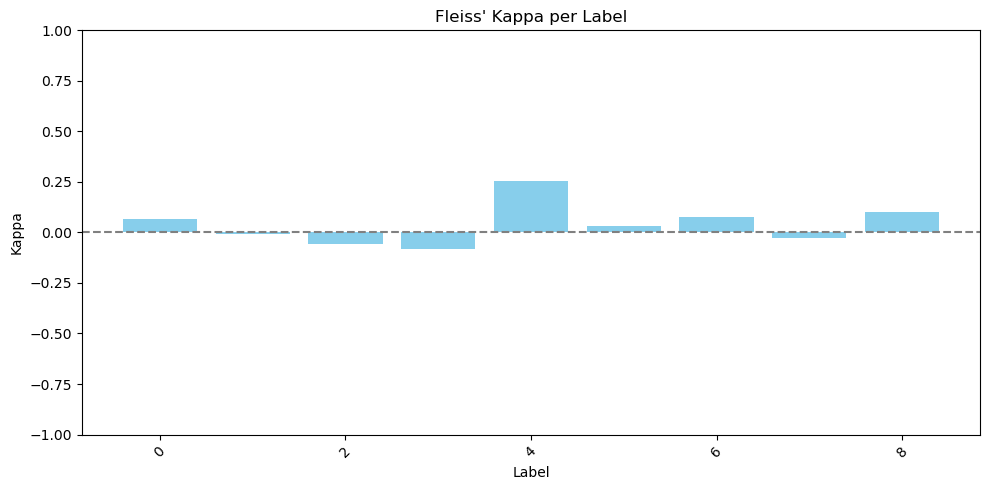

In [16]:
import matplotlib.pyplot as plt

def per_label_kappa(multi_hot_data, label_names):
    """
    Compute Fleiss' Kappa per label independently.
    Returns: dict of {label: kappa}
    """
    label_kappas = {}
    n_items, n_annotators, n_labels = multi_hot_data.shape

    for l in range(n_labels):
        # (n_items, n_annotators) for this label
        data_l = multi_hot_data[:, :, l]
        table = []
        for i in range(n_items):
            counts = np.bincount(data_l[i], minlength=2)
            table.append(counts)
        table = np.array(table)
        kappa = fleiss_kappa(table)
        label_kappas[label_names[l]] = kappa
    return label_kappas

# Compute per-label kappas
label_kappas = per_label_kappa(multi_hot_data, all_labels)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(label_kappas.keys(), label_kappas.values(), color='skyblue')
plt.title("Fleiss' Kappa per Label")
plt.xlabel("Label")
plt.ylabel("Kappa")
plt.ylim(-1, 1)
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [66]:
# Krippendorff's Alpha 
import numpy as np
import pandas as pd

def parse_labels(label_str):
    """Convert a comma-separated string of labels into a set of integers."""
    if label_str == 'NAN' or pd.isna(label_str):
        return set()
    label_str = str(label_str)
    return set(map(int, label_str.split(',')))

def multi_hot_matrix(df, label_set):
    """Convert dataframe of annotator columns into a list of multi-hot matrices per annotator."""
    matrices = []
    for col in df.columns:
        encoded = []
        for label_str in df[col]:
            labels = parse_labels(label_str)
            row = [1 if l in labels else 0 for l in label_set]
            encoded.append(row)
        matrices.append(np.array(encoded))
    return np.stack(matrices, axis=1)  # shape: (n_items, n_annotators, n_labels)

def krippendorffs_alpha(data_matrix):
    """
    Computes Krippendorff's Alpha for multi-label data.
    
    data_matrix: numpy array (n_items, n_annotators, n_labels)
    """
    n_items, n_annotators, n_labels = data_matrix.shape
    
    # Step 1: Calculate observed disagreement
    observed_disagreements = np.zeros((n_items, n_labels))
    for i in range(n_items):
        for l in range(n_labels):
            obs = np.sum(data_matrix[i, :, l])  # How many annotators said "1" for this label
            observed_disagreements[i, l] = (n_annotators - obs) / n_annotators

    # Step 2: Calculate expected disagreement (chance agreement)
    expected_disagreements = np.mean(observed_disagreements, axis=0)
    
    # Step 3: Calculate Krippendorff's alpha using the formula
    D_observed = np.mean(observed_disagreements)
    D_expected = np.mean(expected_disagreements)
    
    alpha = 1 - D_observed / D_expected
    return alpha

# Example dataset (same as previous)
#df = pd.DataFrame({
#    'ann1': ['1,2', '2,5', 'NAN', '4,5,6'],
 #   'ann2': ['1,2', '5', '3', '4,6'],
 #   'ann3': ['2', '2,5,6', 'NAN', '4,5,6']
#})
data = df.drop(df.columns[0], axis=1)
print(data)
# All unique labels used
all_labels = sorted(set().union(*map(parse_labels, data.get(data.keys()[0])))
                    .union(*map(parse_labels, data.get(data.keys()[1])))
                    .union(*map(parse_labels, data.get(data.keys()[2]))))
# Create (n_items, n_annotators, n_labels) multi-hot matrix
multi_hot_data = multi_hot_matrix(data, all_labels)
print(multi_hot_data)
# Compute Krippendorff's Alpha
alpha = krippendorffs_alpha(multi_hot_data)
print(f"Krippendorff's Alpha: {alpha:.3f}")

   Annotator 1 Annotator 2  Annotator 3 
0          1,6          6,8        2,5,6
1            4      3,4,5,7          1,4
2          2,7            3          2,3
3            0            2        2,3,6
4            1          5,6        1,2,3
..         ...          ...          ...
74         0,5          0,8        3,7,8
75           5        3,7,8          1,2
76           0  0,1,2,3,4,5          0,4
77         5,7      0,1,3,6          0,2
78         NAN        0,7,8          6,7

[79 rows x 3 columns]
[[[0 1 0 ... 1 0 0]
  [0 0 0 ... 1 0 1]
  [0 0 1 ... 1 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 1 0]
  [0 1 0 ... 0 0 0]]

 [[0 0 1 ... 0 1 0]
  [0 0 0 ... 0 0 0]
  [0 0 1 ... 0 0 0]]

 ...

 [[1 0 0 ... 0 0 0]
  [1 1 1 ... 0 0 0]
  [1 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 1 0]
  [1 1 0 ... 1 0 0]
  [1 0 1 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [1 0 0 ... 0 1 1]
  [0 0 0 ... 1 1 0]]]
Krippendorff's Alpha: -0.000


In [35]:
!pip install krippendorff

In [27]:
print(multi_hot_data.shape)

(79, 3, 9)


[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 0 0
  1 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 1 0 1 1 1
  0 0 1 1 0 0 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0
  1 1 1 0 0 0 0]]
0.04266134856267037
{0: 0.06860959319975712, 1: -0.0044802867383513245, 2: -0.05405821654089027, 3: -0.07656529516994648, 4: 0.25697151424287856, 5: 0.03436988543371522, 6: 0.08039376538146026, 7: -0.02463228779018256, 8: 0.10334346504559278}


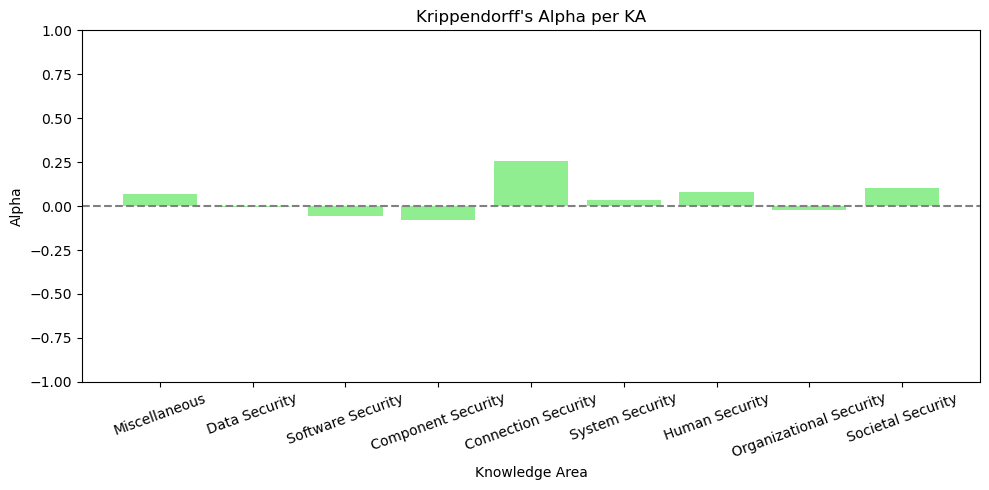

In [67]:
import matplotlib.pyplot as plt
# Compute Krippendorff's Alpha per label
import krippendorff
# now: (items, annotators, labels) 
# needs to be: (labels, items, annotators) 
data2 = np.transpose(multi_hot_data, (2,0,1))
label_alphas = {}
for label_idx, label_data in enumerate(data2): 
    #label_data = np.where(label_data==0, np.nan, label_data)
    #print(label_data.shape)
    item_nan_mask = ~np.all(label_data == 0, axis=(-1))
    filtered_data = label_data 
    alpha = krippendorff.alpha(reliability_data = np.transpose(filtered_data), level_of_measurement='nominal')
    label_alphas[all_labels[label_idx]] = alpha
  #  print(alpha)
print(np.transpose(label_data))
#print(np.transpose(filtered_data))
average_alpha = np.mean(alphas)
print(average_alpha)

print(label_alphas)
# Plot
plt.figure(figsize=(10, 5))
plt.bar(label_alphas.keys(), label_alphas.values(), color='lightgreen')
plt.title("Krippendorff's Alpha per KA")
plt.xlabel("Knowledge Area")
plt.ylabel("Alpha")
plt.ylim(-1, 1)
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(np.arange(9), ['Miscellaneous','Data Security','Software Security','Component Security','Connection Security',
                         'System Security','Human Security','Organizational Security','Societal Security'], rotation=20)
plt.tight_layout()
plt.show()


In [89]:
data3 = [['0,1', '0','1'], ['0','0','0'], ['1', '1', '0']]
alpha3 = krippendorff.alpha(reliability_data = data3, level_of_measurement="nominal")
print(alpha3)

-0.21739130434782616


In [87]:
# replace NAN by np.nan 
labels_coll = []
for row in data.values: 
    dd = []
    for ele in row: 
        if ele == 'NAN': 
            ele = np.nan
        dd.append(ele)
    labels_coll.append(dd)
print(labels_coll)
alpha3 = krippendorff.alpha(reliability_data = labels_coll, level_of_measurement="nominal")
# compare to LLM labels! 
print(alpha3)   
# what if we select all labels for which at least two annotators agree and give the rest 'nan'. 

[['1,6', '6,8', '2,5,6'], [4, '3,4,5,7', '1,4'], ['2,7', 3, '2,3'], [0, 2, '2,3,6'], [1, '5,6', '1,2,3'], ['1,3', nan, 7], [4, 7, '1,2'], ['1,6', 2, nan], [0, 2, '1,4,5,7,8'], [3, 4, '1,2,4'], [2, 2, '1,4,5,6,7'], ['5,6', 2, '1,3,4,5,6'], [1, nan, '0,5,8'], ['1,6', 2, '2,3,4'], ['3,4,5,7', '1,2,5,6', '1,4,5'], ['0,1,5,6,7,8', '1,3,4,5', '0,4,5,6'], ['0,1,7', '3,4,6', nan], ['0,1,4,6,7,8', '0,3,6', '1,5,7,8'], ['1,4', '4,7', 4], ['1,2,5,7', '0,1,8', 5], ['0,2,7', '5,6,7,8', '1,2,3,5'], ['5,6,7,8', 0, '1,2,3'], [5, '3,4,5,7', '1,2,5,6,7'], [5, '1,2,3,4,5', 4], [5, '3,4,5,7', '1,2,5,6'], [5, '4,5', 2], [5, 4, '1,4,7'], [5, '1,2,4,5', '1,4,5'], ['3,4,5,7', nan, 2], ['1,2,3,4,5', 8, 2], ['3,4,5,7', 2, '0,2,5'], [4, '2,5', 5], ['2,4', 1, 2], ['1,2,4,5', '3,6', '0,6,7'], ['1,2,3', 2, '3,5,7'], ['1,2,3,4,5,7', '1,6', '3,5,7'], [2, 3, '2,3,5,6,8'], ['2,4', 3, '2,3,5,7'], ['1,2,4,5', 5, '1,2,3,4,5'], ['1,3,4,5,7,8', '2,4', '0,3,4,5,6,7,8'], ['2,3,4,5,6', '1,5', '0,4,6,7,8'], ['1,2,4,6,7', 2, '0,

In [90]:
# now do this with the jaccard distance 
def jaccard_distance(y1, y2): 
    if isinstance(y1, float) and np.isnan(y1) or isinstance(y2, float) and np.isnan(y2): 
        if np.isnan(y1) and np.isnan(y2): 
            return 0.0 
        else: 
            return np.nan 
    set1 = set(y1.split(',')) if isinstance(y1, str) else set()
    set2 = set(y2.split(',')) if isinstance(y2, str) else set()

    if not set1 and not set2: 
        return 0.0 
    return 1 - len(set1 & set2) / len(set1 | set2) 

alpha3 = krippendorff.alpha(reliability_data = labels_coll, level_of_measurement="nominal", distance_fn = jaccard_distance)
print(alpha3)  

TypeError: alpha() got an unexpected keyword argument 'distance_fn'

In [98]:

from itertools import combinations
from collections import Counter

def jaccard_distance(y1, y2):
    """Compute Jaccard distance between two annotations, handling NaN"""
    if isinstance(y1, float) and np.isnan(y1) or isinstance(y2, float) and np.isnan(y2):
        return np.nan  # Skip if either is missing
   
    set1 = set(str(y1).split(',')) if y1 else set()
    set2 = set(str(y2).split(',')) if y2 else set()
    #print('set1: ',set1)
    #print('set2: ',set2)
    if not set1 and not set2:
        return 0.0  # Agreement on empty labels
    return 1 - len(set1 & set2) / len(set1 | set2)

def krippendorff_alpha(data):
    """Manual computation of Krippendorff's alpha for multi-label data"""
    n_items = len(data)
    n_annotators = len(data[0])
   
    # Compute observed disagreement
    Do = 0
    valid_pairs = 0
   
    for item in data:
        # Get all non-NaN annotations for this item
        annotations = [ann for ann in item if not (isinstance(ann, float) and np.isnan(ann))]
        #print(annotations)
        k = len(annotations)
       
        if k < 2:
            continue  # Skip items with <2 annotations
           
        # Compute all pairwise distances
        item_disagreement = 0
        for (a, b) in combinations(annotations, 2):
            dist = jaccard_distance(a, b)
            #print(dist)
            if not np.isnan(dist):
                item_disagreement += dist
               
        Do += item_disagreement / (k * (k - 1) / 2)
        valid_pairs += 1
   
    if valid_pairs == 0:
        return np.nan
   
    Do /= valid_pairs
   
    # Compute expected disagreement
    all_annotations = [str(ann) for item in data for ann in item
                      if not (isinstance(ann, float) and np.isnan(ann))]
    label_counts = Counter(all_annotations)
    total_labels = len(all_annotations)
   
    De = 0
    labels = list(label_counts.keys())
   
    for i, j in combinations(range(len(labels)), 2):
        li, lj = labels[i], labels[j]
        d = jaccard_distance(li, lj)
        ni = label_counts[li]
        nj = label_counts[lj]
        De += ni * nj * d
   
    De /= (total_labels * (total_labels - 1) / 2)
   
    # Compute alpha
    return 1 - (Do / De) if De != 0 else np.nan

# Example usage
data = [
    ["cat,dog", "cat", np.nan],
    ["dog", np.nan, "dog"],
    ["cat", "cat,dog", "cat"]
]

#alpha = krippendorff_alpha(data)
alpha = krippendorff_alpha(labels_coll)
print(f"Krippendorff's alpha: {alpha}")

Krippendorff's alpha: 0.03204578718904327


In [123]:
# remove items where annotators disagreed the most: 
high_disagreement = [i for i, item in enumerate(labels_coll)
                     if np.nanmean([jaccard_distance(a,b) for a,b in combinations(item,2)]) > 0.8] 
print(len(high_disagreement))
print(len(labels_coll))
mask = np.full(len(labels_coll), True, dtype=bool) 
mask[high_disagreement] = False
labels_coll2 = np.array(labels_coll)
non_disagree = labels_coll2[mask]
print(len(non_disagree))

40
79
39


In [147]:
# remove annotators with consistently high disagreement 
annotator_numbers = [7, 7, 4, 4, 6, 6, 5, 5, 5, 7, 5, 6, 6, 6] 
# loop over separate files 

# compute mean disagreement per annotator across all items 
disagreement_scores = {ann: [] for ann in range(3)}
for item in labels_coll: 
    valid_annotations = [(idx, ann) for idx, ann in enumerate(item) if not (isinstance(ann, float) and np.isnan(ann))] 
    for (ann1_idx, ann1), (ann2_idx, ann2) in combinations(enumerate(valid_annotations), 2): 
        distance = jaccard_distance(ann1, ann2) 
        if not np.isnan(distance): 
            disagreement_scores[ann1_idx].append(distance)
            disagreement_scores[ann2_idx].append(distance)

d = 0
i = 0 
for ann in range(3): 
    for page in annotator_numbers: 
        print(i)
        print(np.mean(disagreement_scores[ann][d:d + page]))
        d += page 
        i += 1 
    
print(np.mean(disagreement_scores[0][:annotator_numbers[0]]))

0
0.9476190476190477
1
1.0
2
1.0
3
0.8854166666666667
4
0.9606481481481483
5
0.9166666666666666
6
0.975
7
1.0
8
1.0
9
1.0
10
1.0
11
0.9444444444444445
12
0.880952380952381
13
0.8598484848484849
14
0.8333333333333334
15
0.901984126984127
16
0.9128787878787878
17
0.975
18
0.9583333333333334
19
0.9791666666666666
20
0.8727272727272727
21
0.9777777777777779
22
0.9261904761904762
23
0.9583333333333333
24
0.96
25
0.915079365079365
26
0.9492063492063492
27
nan
28
nan
29
nan
30
nan
31
nan
32
nan
33
nan
34
nan
35
nan
36
nan
37
nan
38
nan
39
nan
40
nan
41
nan
0.9476190476190477


In [133]:
# re-label items with the most disagreement -> For this Sara and co are the most important. 
item_disagreements = [np.nanmean([jaccard_distance(a, b) for a, b in combinations(item, 2)]) for item in labels_coll] 
worst_items = np.argsort(item_disagreements)[-5:] 
print("relabel these items: ", worst_items)
worst_idxs = [x for x in worst_items]
print(df.get(df.keys()[0])[worst_idxs])

relabel these items:  [51 16 21 75  6]
51                                                 IPv6
16                               Problem-based learning
21    Critically assessing the efficiency of alterna...
75    Key laws and regulations on product liability ...
6                             Virtual environment setup
Name: Topic, dtype: object


In [124]:
alpha = krippendorff_alpha(non_disagree)
print(f"Krippendorff's alpha: {alpha}")

Krippendorff's alpha: 0.12039224065127718


In [ ]:
# extract labels, delimited by ',' and remove NAN entries. 

# compute Cohen's kappa 

# combine labels 

# compute course 'pie chart' 